In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, RobustScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("final_database.csv")
df.shape

(5546, 29)

In [3]:
binary_columns = ['jobma_catcher_status',
                  'jobma_catcher_type',
                  'is_premium',
                  'subscription_type_x',
                  'referral_credit',
                  'ai_live_interview',
                  'subscription_type_y',
                  'plan_type',
                  'is_unlimited',
                  'currency'
                 ]

categorical_columns = ['subscription_status',
                       'per_sub_user',
                       'company_size',
                      ]
                   
ordinal_columns = ['sub_user',#
                   'days_since_creation',#
                   'number_of_logins',#
                   'days_since_login',#
                   'wallet_sum',#
                   'subscription_sum',#
                   'subscription_count',#
                   'ai_kit_counts',#
                   'pre_recorded_kit_counts',#
                   'number_of_jobs_posted',#
                   'number_of_pitcher_invitations',#
                   'number_of_pitchers_applied',#
                   'pre_rec_interviews_counts',#
                   'live_interviews_counts',#
                   'ai_interviews_counts',#done
                   ]

In [4]:
used_columns = binary_columns + categorical_columns + ordinal_columns
X = df[used_columns].copy()
X.shape

(5546, 28)

In [5]:
# Clean binary values , # Remove negatives and  clamp to 0
def clean_binary(X):
    return X.apply(lambda col: col.map(lambda val: 1 if pd.to_numeric(val, errors='coerce') > 0 else 0))
    
def clean_categorical(X):
    return X.apply(lambda col: col.map(lambda val: str(val).strip().lower() if pd.notnull(val) else 'others'))

def clean_ordinal(X):
    return X.clip(lower=0)

In [6]:
#pipeline 
binary_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_binary, validate=False)),
                                  ('imputer', SimpleImputer(strategy='most_frequent'))
                                 ])

categorical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_categorical, validate=False)),
                                       ('imputer', SimpleImputer(strategy='most_frequent')),
                                       ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
                                      ])

ordinal_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_ordinal, validate=False)),
                                   ('imputer', SimpleImputer(strategy='median')),
                                   ('scaler', RobustScaler())
                                  ])

# Combined preprocessor
preprocessor = ColumnTransformer(transformers=[('bin', binary_pipeline, binary_columns),
                                               ('cat', categorical_pipeline, categorical_columns),
                                               ('ord', ordinal_pipeline, ordinal_columns)
                                              ])

pipeline = Pipeline([('preprocessing', preprocessor),
                     # ('scaling', MinMaxScaler()) #Problem shoul i use or not
                    ])

In [7]:
pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('bin',
                                                  Pipeline(steps=[('cleaner',
                                                                   FunctionTransformer(func=<function clean_binary at 0x0000020ECCFA0430>)),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['jobma_catcher_status',
                                                   'jobma_catcher_type',
                                                   'is_premium',
                                                   'subscription_type_x',
                                                   'referral_credit',
                                                   'ai_live_interview',
                                                   'subscrip...
                                                                   RobustScaler())]),
                                                  ['sub_user',
                                                   'days_since_creation',
                                                   'number_of_logins',
                                                   'days_since_login',
                                                   'wallet_sum',
                                                   'subscription_sum',
                                                   'subscription_count',
                                                   'ai_kit_counts',
                                                   'pre_recorded_kit_counts',
                                                   'number_of_jobs_posted',
                                                   'number_of_pitcher_invitations',
                                                   'number_of_pitchers_applied',
                                                   'pre_rec_interviews_counts',
                                                   'live_interviews_counts',
                                                   'ai_interviews_counts'])]))])

In [8]:
X_processed = pipeline.fit_transform(X)

In [9]:
X_processed.shape

(5546, 42)

DBSCAN found 136 clusters and 2336 noise points.
Silhouette Score (excluding noise): 0.631


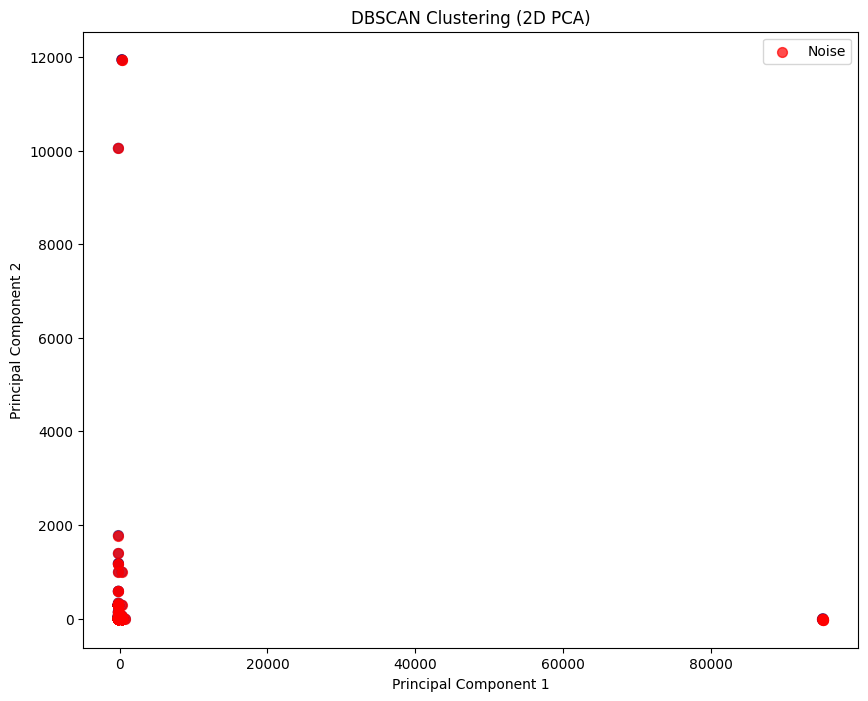

In [10]:
# DBSCAN Clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_processed)

# Print the results
print(f"DBSCAN found {len(set(labels)) - (1 if -1 in labels else 0)} clusters and {list(labels).count(-1)} noise points.")

# Calculate silhouette score excluding noise
if len(set(labels)) > 1 and list(labels).count(-1) < len(labels):
    mask = labels != -1
    sil_score = silhouette_score(X_processed[mask], labels[mask])
    print(f"Silhouette Score (excluding noise): {sil_score:.3f}")
else:
    print("Silhouette Score is not applicable due to only one cluster or too many noise points.")

# Dimensionality reduction using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

# Create a scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)

# Highlight noise points (DBSCAN labels -1)
plt.scatter(X_pca[labels == -1, 0], X_pca[labels == -1, 1], color='red', s=50, label='Noise', alpha=0.7)

# Add labels and title
plt.title("DBSCAN Clustering (2D PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

DBSCAN found 136 clusters and 2336 noise points.
Silhouette Score (excluding noise): 0.631


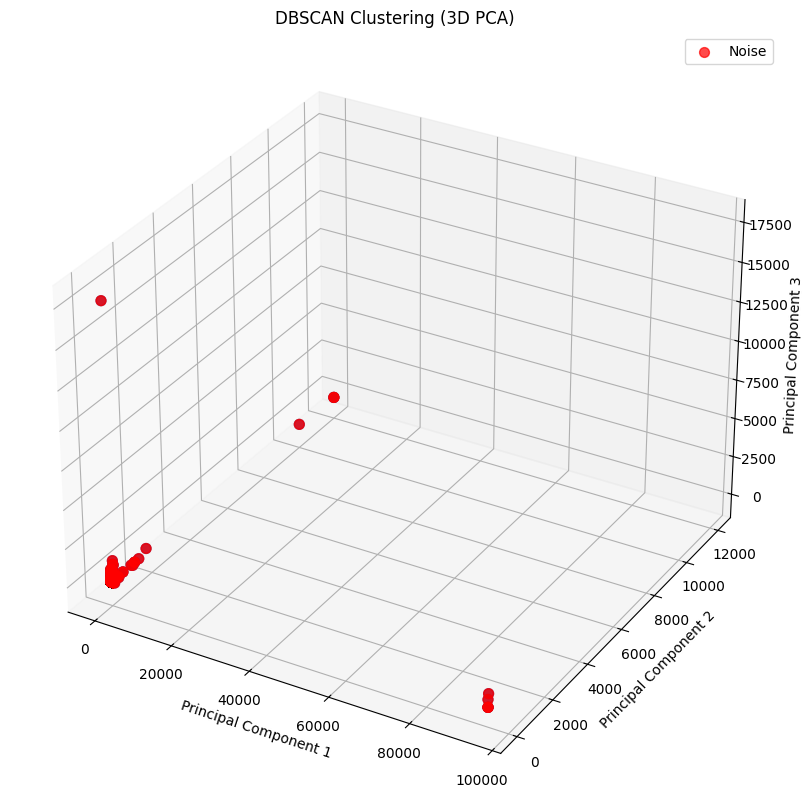

In [11]:
from mpl_toolkits.mplot3d import Axes3D

# Perform PCA for 3 components
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_processed)

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_processed)

# Print the results
print(f"DBSCAN found {len(set(labels)) - (1 if -1 in labels else 0)} clusters and {list(labels).count(-1)} noise points.")

# Calculate silhouette score excluding noise
if len(set(labels)) > 1 and list(labels).count(-1) < len(labels):
    mask = labels != -1
    sil_score = silhouette_score(X_processed[mask], labels[mask])
    print(f"Silhouette Score (excluding noise): {sil_score:.3f}")
else:
    print("Silhouette Score is not applicable due to only one cluster or too many noise points.")

# Create a 3D scatter plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of the PCA-reduced data points
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=labels, cmap='viridis', s=50, alpha=0.7)

# Highlight noise points (DBSCAN labels -1)
ax.scatter(X_pca_3d[labels == -1, 0], X_pca_3d[labels == -1, 1], X_pca_3d[labels == -1, 2], color='red', s=50, label='Noise', alpha=0.7)

# Add labels and title
ax.set_title("DBSCAN Clustering (3D PCA)")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.legend()

# Show the plot
plt.show()